# Árvore de decisão — `causal_business_v2` e `causal_large_v2`

Ajusta uma `DecisionTreeRegressor` sobre `y` em cada dataset e mostra a hierarquia de splits,
comparando as variáveis escolhidas contra os *parents* verdadeiros de `y` (`metadata.json`).

Duas variantes por dataset:
1. **todas as features** (canais + controles)
2. **só canais** — os controles são tendências que dominam a árvore inteira

> **Ambiente (NixOS):** a `.venv` precisa de `libstdc++`/`libz` no `LD_LIBRARY_PATH`. Para rodar fora deste notebook:
> ```bash
> export LD_LIBRARY_PATH=/nix/store/ybp235ps7m4yd85v0pgvqkhd4xmxf6jq-gcc-14.3.0-lib/lib:/nix/store/lf793zr9yfa0dpph8jlxbbdnvnahvq8b-zlib-1.3.2/lib:$LD_LIBRARY_PATH
> ```

In [1]:
%matplotlib inline
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import cross_val_score, KFold

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASETS = ["causal_business_v2", "causal_large_v2"]
MAX_DEPTH, MIN_LEAF, SEED = 4, 10, 0

def load(ds):
    base = ROOT / "datasets" / ds
    df = pd.read_csv(base / "data.csv")
    meta = json.loads((base / "metadata.json").read_text())
    parents = {e["source"] for e in meta["true_edges"] if e["target"] == "y"}
    return df, meta, parents

print(f"root: {ROOT}")

root: /home/rafael.ennes/Documents/mestrado/causalmmm_cdnots


In [2]:
def fit_tree(X, y, parents, title, plot=True):
    tree = DecisionTreeRegressor(max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF, random_state=SEED).fit(X, y)
    cv = cross_val_score(tree, X, y, cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2").mean()
    print(f"=== {title} | features={X.shape[1]} | R2 in-sample={tree.score(X, y):.3f} | R2 CV(5)={cv:.3f} ===\n")
    print(export_text(tree, feature_names=list(X.columns), decimals=0))

    imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
    imp = imp[imp > 0]
    tag = lambda k: "PARENT de y" if k in parents else ("ghost" if "Ghost" in k else "nao-parent")
    table = pd.DataFrame({"importancia": imp.round(3), "papel": [tag(k) for k in imp.index]})
    used = set(imp.index)
    print(f"cobertura de parents: {len(used & parents)}/{len(parents)}"
          f" | selecionados que NAO sao parent: {sorted(used - parents)}\n")
    display(table)

    if plot:
        fig, ax = plt.subplots(figsize=(22, 9))
        plot_tree(tree, feature_names=list(X.columns), filled=True, rounded=True,
                  fontsize=8, precision=0, impurity=False, ax=ax)
        ax.set_title(title)
        plt.tight_layout()
        plt.show()
    return tree, table

## `causal_business_v2`

In [3]:
df_b, meta_b, parents_b = load("causal_business_v2")
print(f"n={len(df_b)}  canais={meta_b['n_channels']}  controles={meta_b['n_controls']}  ghosts={meta_b['ghost_names']}")
print(f"parents reais de y ({len(parents_b)}): {sorted(parents_b)}")
df_b.head()

n=156  canais=8  controles=1  ghosts=['x7_Ghost-A', 'x8_Ghost-B']
parents reais de y (6): ['x1_Search-Ads', 'x2_Brand-Search', 'x3_TV', 'x4_Video', 'x5_Social-Media', 'x6_Display-Ads']


,x1_Search-Ads,x2_Brand-Search,x3_TV,x4_Video,x5_Social-Media,x6_Display-Ads,x7_Ghost-A,x8_Ghost-B,c1,y
0,1774.420674,1835.137542,4978.625523,2260.883968,2746.935508,1684.602946,2628.016052,0.000000,0.0,48870.614711
1,2100.255880,1944.181295,5354.396621,2228.488209,3216.872237,1628.200644,1941.611498,0.000000,0.0,53112.577864
2,3071.567411,2519.332740,5206.320455,2206.583107,3314.696680,0.000000,2384.682023,0.000000,0.0,54671.305215
3,3363.548587,2060.348136,5277.566624,3249.128408,2980.853633,1937.906007,2594.536728,0.000000,0.0,56152.610141
4,2832.291299,2367.746901,5063.431923,3001.715273,3310.628701,2023.159763,2334.458745,1907.399549,0.0,57342.587086


=== causal_business_v2 — todas as features | features=9 | R2 in-sample=0.924 | R2 CV(5)=0.807 ===

|--- c1 <= 64
|   |--- x1_Search-Ads <= 4016
|   |   |--- value: [56285]
|   |--- x1_Search-Ads >  4016
|   |   |--- x2_Brand-Search <= 2194
|   |   |   |--- x6_Display-Ads <= 1261
|   |   |   |   |--- value: [56988]
|   |   |   |--- x6_Display-Ads >  1261
|   |   |   |   |--- value: [59901]
|   |   |--- x2_Brand-Search >  2194
|   |   |   |--- value: [61207]
|--- c1 >  64
|   |--- c1 <= 122
|   |   |--- c1 <= 103
|   |   |   |--- x1_Search-Ads <= 5694
|   |   |   |   |--- value: [66847]
|   |   |   |--- x1_Search-Ads >  5694
|   |   |   |   |--- value: [64811]
|   |   |--- c1 >  103
|   |   |   |--- x4_Video <= 3344
|   |   |   |   |--- value: [66625]
|   |   |   |--- x4_Video >  3344
|   |   |   |   |--- value: [71728]
|   |--- c1 >  122
|   |   |--- x2_Brand-Search <= 2273
|   |   |   |--- c1 <= 129
|   |   |   |   |--- value: [71551]
|   |   |   |--- c1 >  129
|   |   |   |   |--- val

,importancia,papel
c1,0.924,nao-parent
x4_Video,0.027,PARENT de y
x1_Search-Ads,0.021,PARENT de y
x2_Brand-Search,0.018,PARENT de y
x6_Display-Ads,0.010,PARENT de y


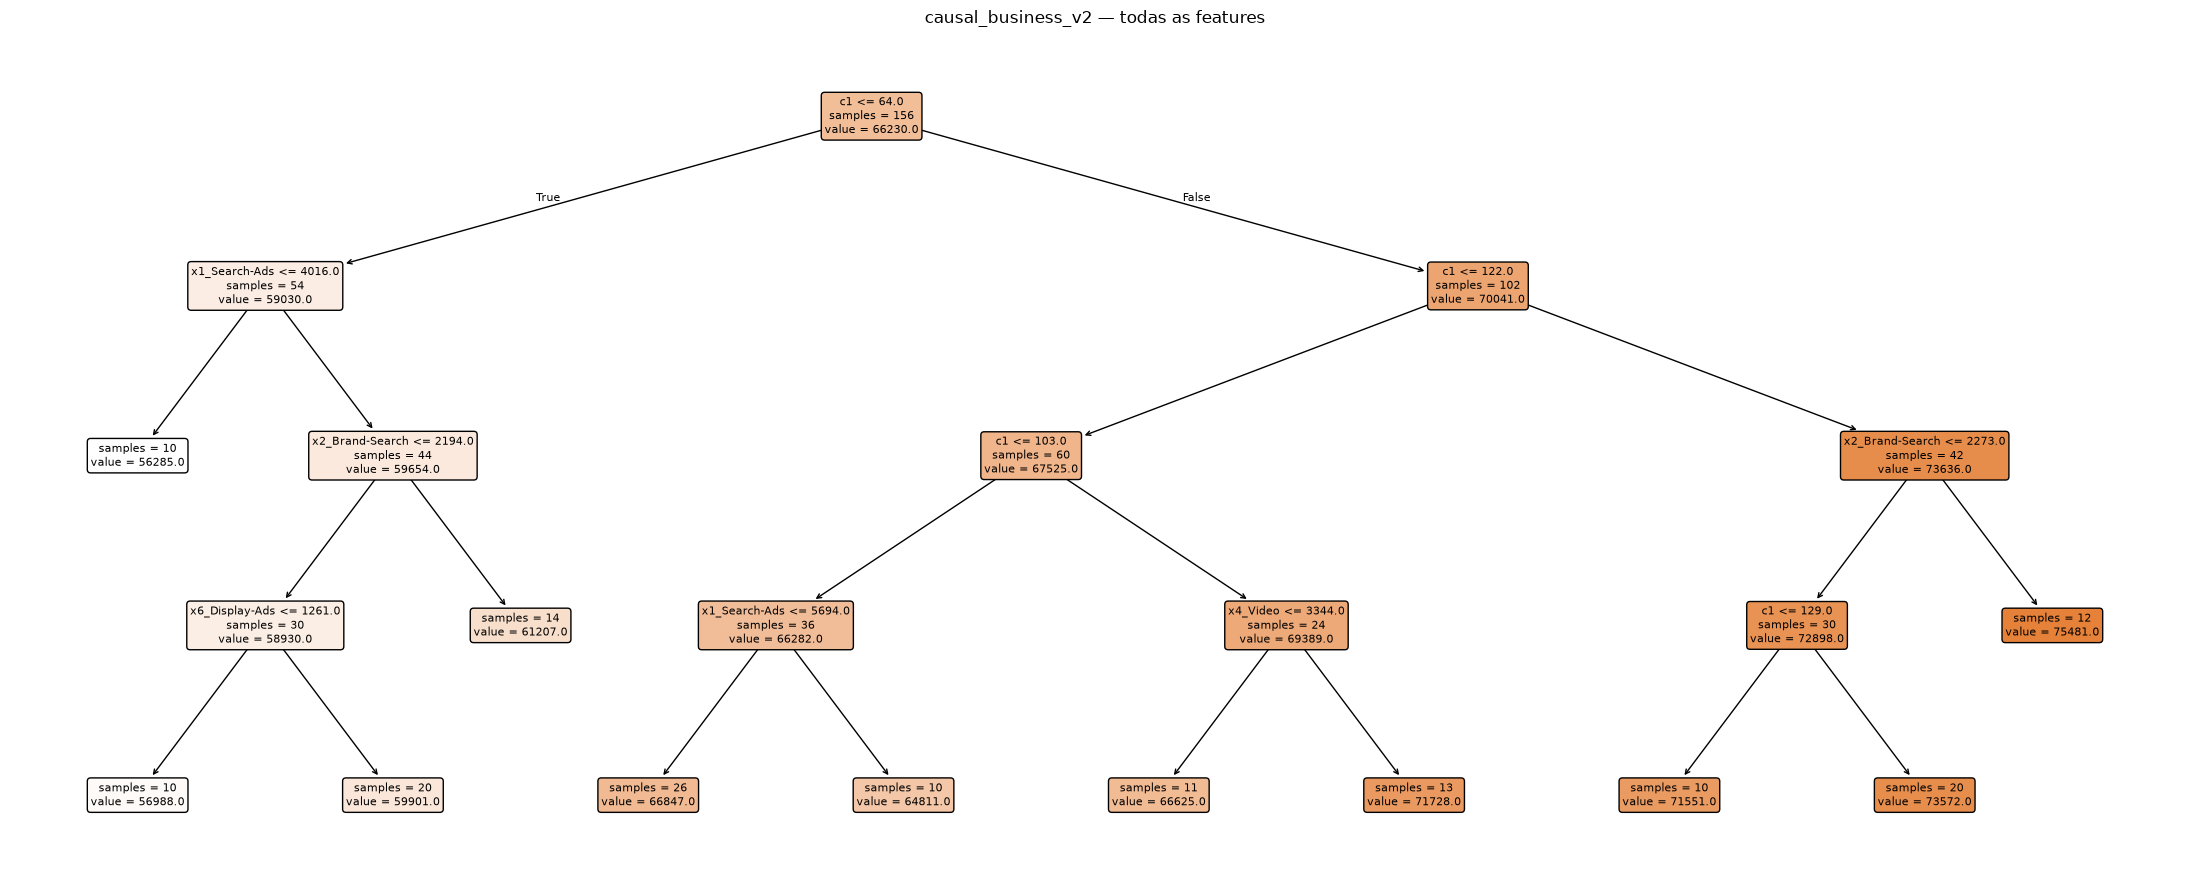

In [4]:
tree_b_all, imp_b_all = fit_tree(df_b.drop(columns=["y"]), df_b["y"], parents_b,
                                 "causal_business_v2 — todas as features")

=== causal_business_v2 — só canais | features=8 | R2 in-sample=0.761 | R2 CV(5)=0.506 ===

|--- x4_Video <= 3306
|   |--- x1_Search-Ads <= 5274
|   |   |--- x1_Search-Ads <= 4016
|   |   |   |--- value: [56285]
|   |   |--- x1_Search-Ads >  4016
|   |   |   |--- x6_Display-Ads <= 1687
|   |   |   |   |--- value: [59408]
|   |   |   |--- x6_Display-Ads >  1687
|   |   |   |   |--- value: [62759]
|   |--- x1_Search-Ads >  5274
|   |   |--- x4_Video <= 2864
|   |   |   |--- value: [64182]
|   |   |--- x4_Video >  2864
|   |   |   |--- value: [67941]
|--- x4_Video >  3306
|   |--- x1_Search-Ads <= 6218
|   |   |--- x4_Video <= 3587
|   |   |   |--- x8_Ghost-B <= 1503
|   |   |   |   |--- value: [69399]
|   |   |   |--- x8_Ghost-B >  1503
|   |   |   |   |--- value: [65948]
|   |   |--- x4_Video >  3587
|   |   |   |--- x1_Search-Ads <= 5143
|   |   |   |   |--- value: [68793]
|   |   |   |--- x1_Search-Ads >  5143
|   |   |   |   |--- value: [72589]
|   |--- x1_Search-Ads >  6218
|   |   |

,importancia,papel
x4_Video,0.689,PARENT de y
x1_Search-Ads,0.269,PARENT de y
x6_Display-Ads,0.023,PARENT de y
x8_Ghost-B,0.014,ghost
x2_Brand-Search,0.005,PARENT de y


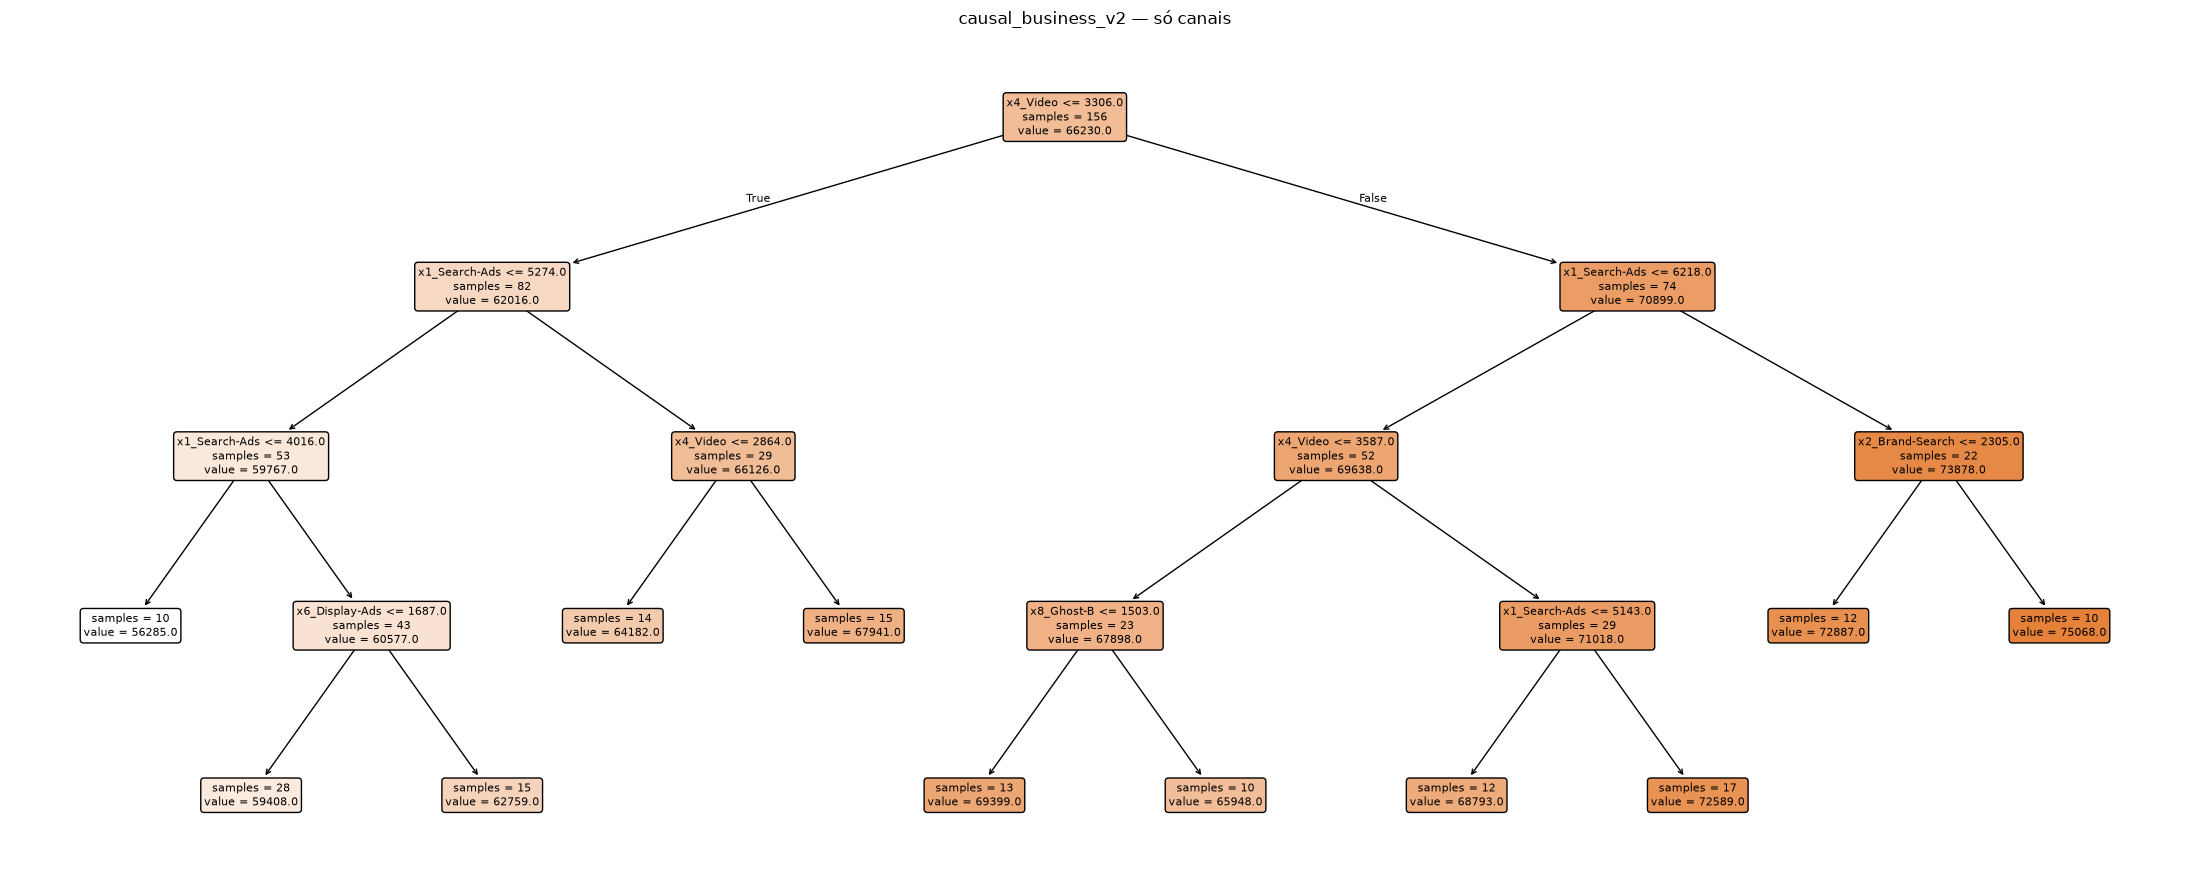

In [5]:
tree_b_ch, imp_b_ch = fit_tree(df_b[meta_b["channel_names"]], df_b["y"], parents_b,
                               "causal_business_v2 — só canais")

## `causal_large_v2`

In [6]:
df_l, meta_l, parents_l = load("causal_large_v2")
print(f"n={len(df_l)}  canais={meta_l['n_channels']}  controles={meta_l['n_controls']}  ghosts={meta_l['ghost_names']}")
print(f"parents reais de y ({len(parents_l)}): {sorted(parents_l)}")
df_l.head()

n=208  canais=22  controles=10  ghosts=['x21_Ghost-A', 'x22_Ghost-B']
parents reais de y (20): ['x10_Native-Ads', 'x11_Paid-Search', 'x12_Brand-Search', 'x13_Shopping-Ads', 'x14_Retargeting', 'x15_Affiliate', 'x16_CTV', 'x17_Streaming-Audio', 'x18_Influencer', 'x19_Email', 'x1_TV', 'x20_Push-Notif', 'x2_OOH', 'x3_Radio', 'x4_Podcast', 'x5_Video', 'x6_Social-Paid', 'x7_Social-Organic', 'x8_Display', 'x9_Programmatic']


,x10_Native-Ads,x11_Paid-Search,x12_Brand-Search,x13_Shopping-Ads,x14_Retargeting,x15_Affiliate,x16_CTV,x17_Streaming-Audio,x18_Influencer,x19_Email,...,c10,c2,c3,c4,c5,c6,c7,c8,c9,y
0,1539.946105,5441.264341,2833.611676,3981.666575,1760.595163,1337.219072,1421.740953,729.992201,1447.166089,712.250780,...,0.0,0.0,95.877778,6118.007620,86.252128,1.266039,0.0,0.0,23.418510,368778.734615
1,1532.598920,5334.337467,2718.835701,3493.251521,1318.787731,1253.153702,2000.471246,897.292419,1027.710566,757.840579,...,0.0,0.0,96.593366,5931.246333,88.131064,1.280762,0.0,0.0,22.876432,415776.027306
2,1348.752045,7065.744022,2627.498025,3619.452115,2081.564042,1265.131351,1750.050934,612.805001,1772.228795,714.360722,...,0.0,0.0,97.239307,5893.709472,88.300930,1.285288,0.0,0.0,23.654392,430392.696770
3,1371.492877,8576.224387,3448.408024,4478.982134,1507.625682,1296.186016,2306.515474,909.154671,1114.878952,731.688475,...,0.0,0.0,99.107252,7795.591223,85.388276,1.260189,0.0,0.0,21.988300,437751.113341
4,1697.351732,10421.960786,3657.086191,4123.885359,1819.660593,1158.168129,1898.755220,588.315685,1687.554146,686.335987,...,0.0,0.0,100.349675,5924.366759,86.960849,1.255270,0.0,0.0,22.002818,456713.779571


=== causal_large_v2 — todas as features | features=32 | R2 in-sample=0.974 | R2 CV(5)=0.959 ===

|--- c3 <= 195
|   |--- c3 <= 143
|   |   |--- c1 <= 119
|   |   |   |--- value: [440462]
|   |   |--- c1 >  119
|   |   |   |--- x2_OOH <= 2773
|   |   |   |   |--- value: [457497]
|   |   |   |--- x2_OOH >  2773
|   |   |   |   |--- value: [467254]
|   |--- c3 >  143
|   |   |--- c3 <= 159
|   |   |   |--- value: [487159]
|   |   |--- c3 >  159
|   |   |   |--- c1 <= 273
|   |   |   |   |--- value: [499814]
|   |   |   |--- c1 >  273
|   |   |   |   |--- value: [512503]
|--- c3 >  195
|   |--- c3 <= 248
|   |   |--- c3 <= 210
|   |   |   |--- value: [529280]
|   |   |--- c3 >  210
|   |   |   |--- c3 <= 236
|   |   |   |   |--- value: [545212]
|   |   |   |--- c3 >  236
|   |   |   |   |--- value: [553967]
|   |--- c3 >  248
|   |   |--- c3 <= 290
|   |   |   |--- c6 <= 1
|   |   |   |   |--- value: [586480]
|   |   |   |--- c6 >  1
|   |   |   |   |--- value: [575706]
|   |   |--- c3 >  

,importancia,papel
c3,0.985,nao-parent
c1,0.011,nao-parent
c6,0.002,nao-parent
x2_OOH,0.002,PARENT de y


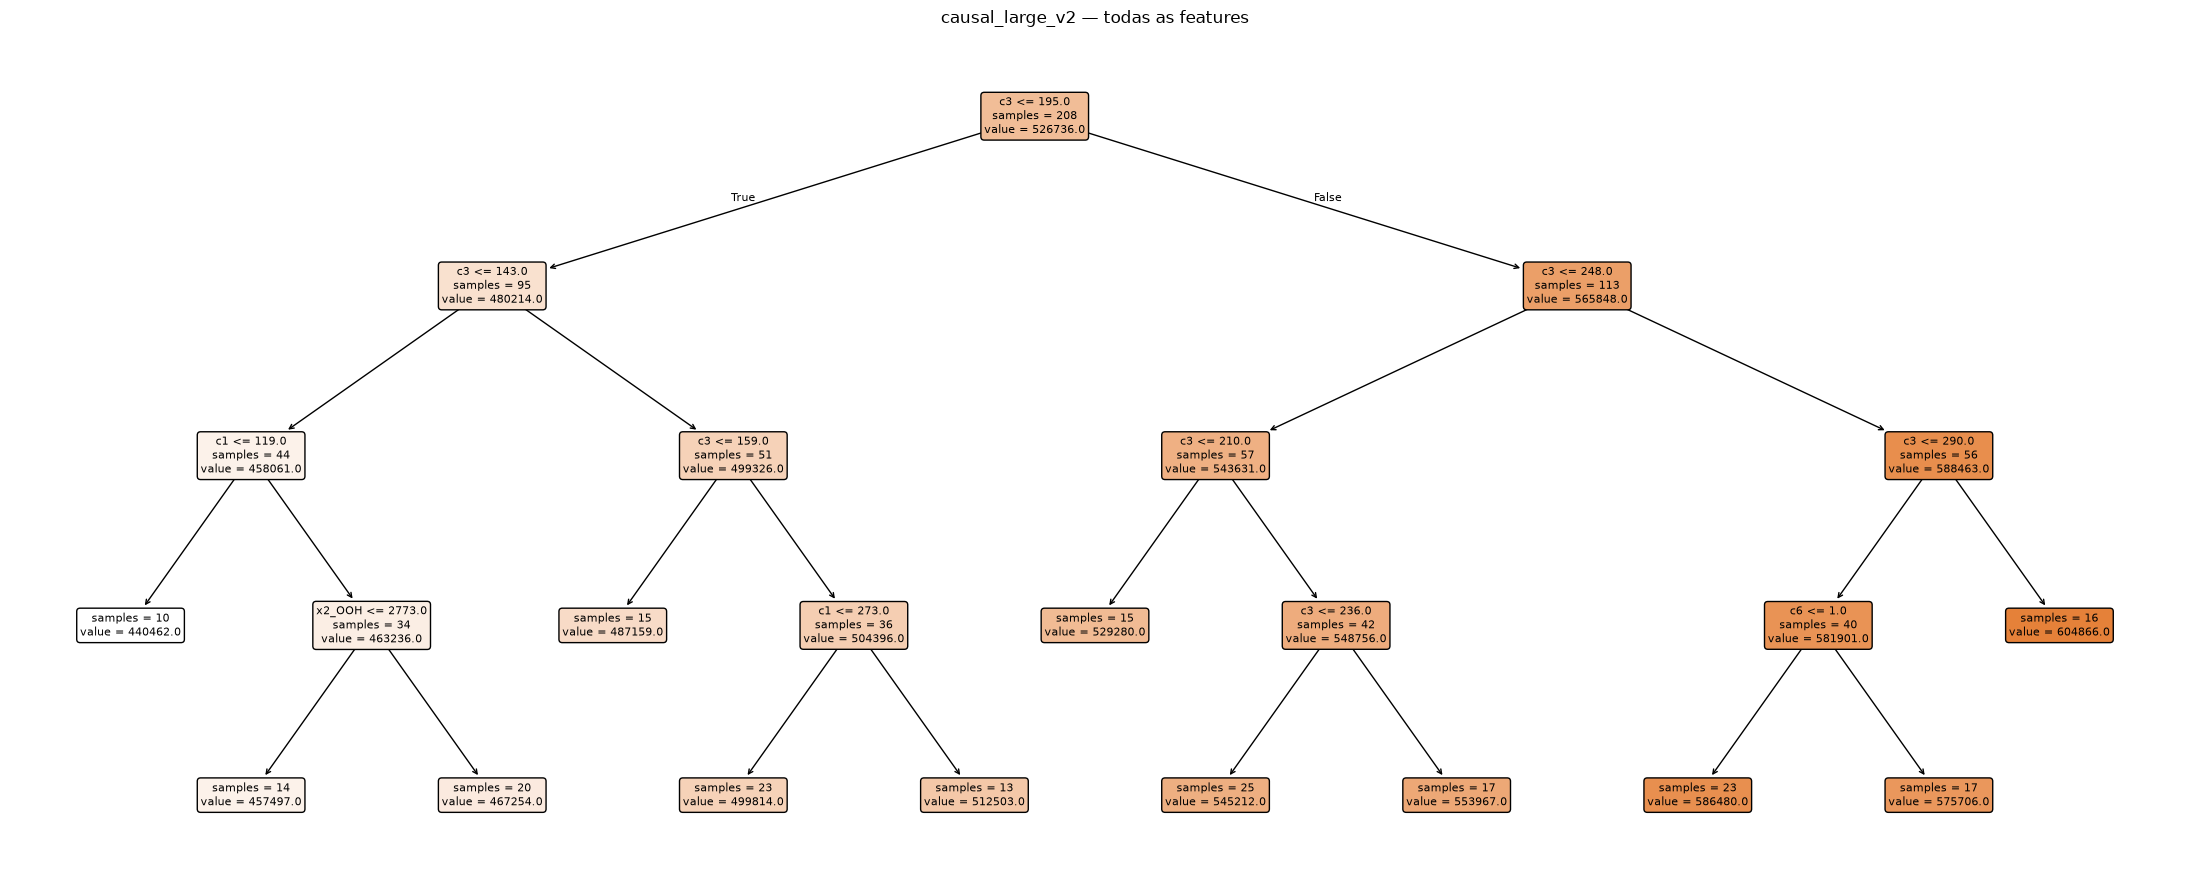

In [7]:
tree_l_all, imp_l_all = fit_tree(df_l.drop(columns=["y"]), df_l["y"], parents_l,
                                 "causal_large_v2 — todas as features")

=== causal_large_v2 — só canais | features=22 | R2 in-sample=0.892 | R2 CV(5)=0.763 ===

|--- x16_CTV <= 3350
|   |--- x15_Affiliate <= 1360
|   |   |--- x5_Video <= 4170
|   |   |   |--- value: [449162]
|   |   |--- x5_Video >  4170
|   |   |   |--- value: [478554]
|   |--- x15_Affiliate >  1360
|   |   |--- x17_Streaming-Audio <= 920
|   |   |   |--- value: [472938]
|   |   |--- x17_Streaming-Audio >  920
|   |   |   |--- x1_TV <= 8642
|   |   |   |   |--- value: [500439]
|   |   |   |--- x1_TV >  8642
|   |   |   |   |--- value: [482192]
|--- x16_CTV >  3350
|   |--- x16_CTV <= 4083
|   |   |--- x5_Video <= 6335
|   |   |   |--- value: [505532]
|   |   |--- x5_Video >  6335
|   |   |   |--- x15_Affiliate <= 1599
|   |   |   |   |--- value: [537989]
|   |   |   |--- x15_Affiliate >  1599
|   |   |   |   |--- value: [553059]
|   |--- x16_CTV >  4083
|   |   |--- x17_Streaming-Audio <= 1493
|   |   |   |--- x19_Email <= 584
|   |   |   |   |--- value: [548905]
|   |   |   |--- x19_Emai

,importancia,papel
x16_CTV,0.844,PARENT de y
x5_Video,0.061,PARENT de y
x17_Streaming-Audio,0.039,PARENT de y
x15_Affiliate,0.035,PARENT de y
x1_TV,0.013,PARENT de y
x19_Email,0.008,PARENT de y


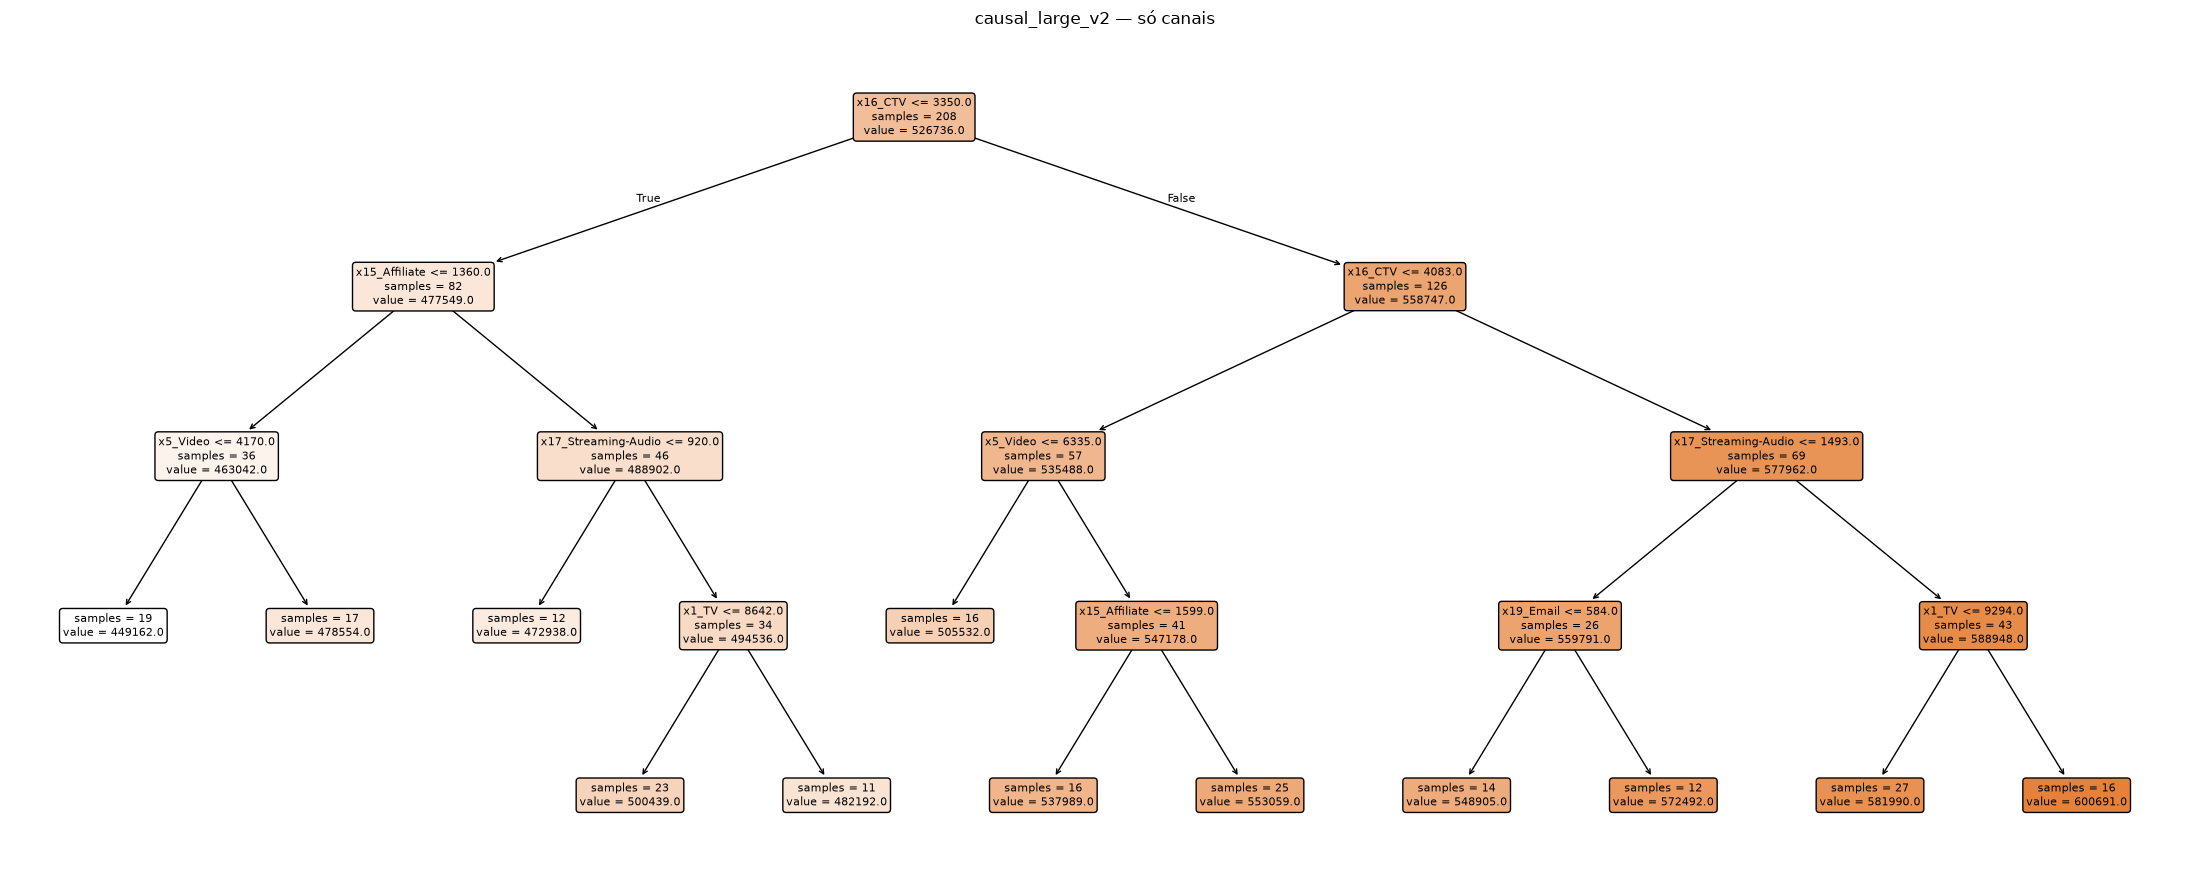

In [8]:
tree_l_ch, imp_l_ch = fit_tree(df_l[meta_l["channel_names"]], df_l["y"], parents_l,
                               "causal_large_v2 — só canais")

## Por que os controles dominam

In [9]:
rows = []
for ds, df, meta in [("causal_business_v2", df_b, meta_b), ("causal_large_v2", df_l, meta_l)]:
    t = np.arange(len(df))
    for c in meta["control_names"]:
        rows.append({"dataset": ds, "controle": c,
                     "corr_com_tempo": round(float(np.corrcoef(df[c], t)[0, 1]), 3),
                     "corr_com_y": round(float(np.corrcoef(df[c], df["y"])[0, 1]), 3)})
pd.DataFrame(rows).sort_values("corr_com_y", ascending=False, key=abs).reset_index(drop=True)

,dataset,controle,corr_com_tempo,corr_com_y
0,causal_large_v2,c3,0.999,0.985
1,causal_large_v2,c1,0.998,0.983
2,causal_business_v2,c1,0.943,0.918
3,causal_large_v2,c7,-0.233,-0.221
4,causal_large_v2,c5,0.018,0.055
5,causal_large_v2,c8,-0.048,-0.045
6,causal_large_v2,c9,-0.007,0.030
7,causal_large_v2,c6,-0.014,0.023
8,causal_large_v2,c4,-0.038,-0.011
9,causal_large_v2,c2,-0.020,0.007


## Leitura

- `c1` (business) e `c3` (large) são **tendências** — a árvore com controles aprende o trend, não a resposta de mídia.
  Para qualquer leitura causal, ou os controles saem, ou `y` é destendenciado antes.
- Mesmo só com canais, a árvore é um **seletor marginal**: escolhe quem explica mais variância sozinho e
  ignora mediadores (`x3_TV → x1_Search-Ads`, `x5_Social-Media → x2_Brand-Search` no business) — o buraco
  que PCMCI/CD-NOTS existe para cobrir.
- No business a árvore ainda seleciona um **ghost** (`x8_Ghost-B`), variável sem aresta verdadeira nenhuma.
- No large, `max_depth=4` limita a árvore a ~6 variáveis: cobertura 6/20 é teto estrutural, não sinal de que
  os outros 14 canais não afetam `y`.